In [1]:
%matplotlib widget

import os
import numpy as np
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
import pytesseract


In [2]:
# Load image into a NumPy array

img_path = "frames/split2.png"
if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found: {img_path}")

def load_rdb(img_path):
    return np.array(Image.open(img_path).convert("RGB"))

img_np = load_rdb(img_path)

print(f"Loaded {img_path}")
print(f"shape: {img_np.shape}, dtype: {img_np.dtype}")

Loaded frames/split2.png
shape: (1080, 2280, 3), dtype: uint8


In [3]:
import cv2
import numpy as np

bgr = img_np.copy()
min_area_ratio=0.001

H, W = bgr.shape[:2]
min_area = min_area_ratio * H * W

# Grayscale + slight blur to reduce noise
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (3, 3), 0)  # lighter blur

# Edge detection with lower thresholds for thin edges
edges = cv2.Canny(gray, 50, 150) # Default
contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

quads = []
for i, c in enumerate(contours):
    if hierarchy[0][i][3] != -1:  # [3] is parent index
        continue
    
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.05 * peri, True)
    
    if len(approx) == 4 and cv2.contourArea(approx) >= min_area and cv2.isContourConvex(approx):
        quads.append(approx.reshape(-1, 2).astype(np.float32))

In [4]:
player_cards_x_slice = slice(800, 1500, None)
player_cards_y_slice = slice(400, 675, None)


In [5]:
import cv2
import numpy as np

def find_subimages(main_img, templates, threshold=0.8):
    """
    Find multiple template images in main image
    
    Args:
        main_img_path: Path to main image
        template_paths: List of paths to template images
        threshold: Matching confidence (0-1)
    
    Returns:
        List of matches with locations
    """    
    # Avoid list aliasing so each template has its own match list
    matches = [[] for _ in range(len(templates))]
    
    for i, template in enumerate(templates):
        h = template.shape[0]
        w = template.shape[1]
        # Perform template matching
        result = cv2.matchTemplate(main_img, template, cv2.TM_CCOEFF_NORMED)
        filter_size = min(h, w)
        peaks = find_peaks(result, filter_size)
        result[~peaks] = 0
        # Find all matches above threshold
        locations = np.where(result >= threshold)
        
        locations_xy = locations[::-1]
        for pt in zip(*locations_xy):
            matches[i].append([
                np.array([pt[0], pt[1]]),
                np.array([pt[0] + w, pt[1] + h]),
                result[pt[1], pt[0]]
            ])

    return matches

def find_peaks(result, filter_size):
    # Create a dilated version (local maximum filter)
    kernel = np.ones((filter_size, filter_size), np.uint8)
    local_max = cv2.dilate(result, kernel)
    peaks = (result == local_max)
    return peaks

In [6]:
templates = []
for suit in "shcd":
    templates.append(load_rdb(f"suits/{suit}.png"))
matches = find_subimages(img_np, templates, threshold=0.9)

(0.0, 0.0, 0.0)
(1.0, 0.0, 0.0)
(0.0, 0.7, 0.0)
(0.0, 0.0, 1.0)


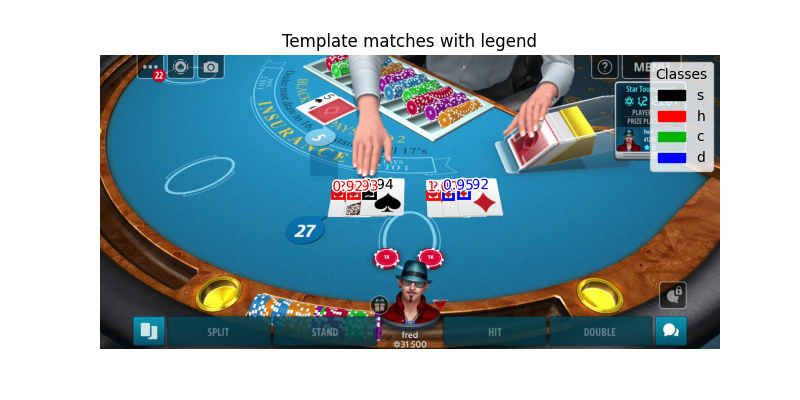

In [7]:
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# Single annotated image with legend for 4 classes: s, h, c, d
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.imshow(img_np)
ax.set_axis_off()
ax.set_title("Template matches with legend")

# Define class labels in the same order as templates were added: "shcd"
suit_labels = ["s", "h", "c", "d"]

# Define distinct RGB colors for legend (0-1 range)
colors_rgb = [
    (0.0, 0.0, 0.0),   # black
    (1.0, 0.0, 0.0),   # red
    (0.0, 0.7, 0.0),   # green
    (0.0, 0.0, 1.0),   # blue
]

# Draw detections with Matplotlib
for i, mlist in enumerate(matches):
    color = colors_rgb[i]
    print(color)
    for (tl, br, score) in mlist:
        x0, y0 = int(tl[0]), int(tl[1])
        x1, y1 = int(br[0]), int(br[1])
        w, h = x1 - x0, y1 - y0
        rect = Rectangle((x0, y0), w, h, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        ax.text(
            x0, y0, f"{float(score):.2f}", color=color, fontsize=10,
            path_effects=[pe.withStroke(linewidth=2, foreground="white")]
        )

# Build legend handles (always show up to the number of templates)
handles = [mpatches.Patch(color=colors_rgb[i], label=suit_labels[i]) for i in range(min(len(suit_labels), len(templates)))]
ax.legend(handles=handles, title="Classes", loc="upper right")
plt.show()

In [8]:
# Build label rectangles for each match across all groups
# Rectangle spans horizontally: left -> right+10, vertically: top-45 -> top
# Output as list of ((x0, y0), (x1, y1)) in image coordinates
digits = []
H, W = img_np.shape[:2]

for mlist in matches:
    for (tl, br, score) in mlist:
        x_left = int(min(tl[0], br[0]))
        x_right = int(max(tl[0], br[0])) + 10
        top = int(min(tl[1], br[1]))  # y increases downward; top is the smaller y
        y0 = max(0, top - 40)
        y1 = min(H, top)
        x0 = max(0, x_left)
        x1 = min(W, x_right + 10)
        if x1 > x0 and y1 > y0:
            digits.append(img_np[y0:y1, x0:x1])

# Quick sanity output
print(f"Built {len(digits)} digits")

Built 6 digits


In [9]:
def to_bnw(img_rgb: np.ndarray) -> np.ndarray:
    """
    Convert an RGB image to binary black/white such that:
    - Red regions become black (0)
    - Blue regions become white (255)
    - Dark/black text also becomes black
    - Remaining background defaults to white
    Returns a 2D uint8 image (0/255).
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    
    # Red wraps around in HSV
    red1 = cv2.inRange(hsv, np.array([0, 80, 50]),  np.array([10, 255, 255]))
    red2 = cv2.inRange(hsv, np.array([170, 80, 50]), np.array([180, 255, 255]))
    red_mask = cv2.bitwise_or(red1, red2)
    
    # Blue range in HSV
    blue_mask = cv2.inRange(hsv, np.array([100, 80, 40]), np.array([140, 255, 255]))
    
    # Dark pixels (black text, outlines, etc.) from grayscale
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    dark_mask = (gray < 80).astype(np.uint8) * 255
    
    # Start with white background
    bnw = np.full_like(gray, 255)
    
    # Apply mappings
    bnw[blue_mask > 0] = 255     # blue -> white (explicit, though default is white)
    bnw[red_mask > 0] = 0        # red -> black
    bnw[dark_mask > 0] = 0       # dark -> black

    return bnw

In [10]:
def preprocess_for_better_results(img):
    
    # Increase contrast
    img = cv2.equalizeHist(img)
    
    # Denoise
    img = cv2.fastNlMeansDenoising(img)
    
    # Binarize (if character is dark on light or vice versa)
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return img

In [11]:
import emnist_predictor

2025-10-12 14:38:42.287879: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-12 14:38:42.327244: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-12 14:38:43.216035: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


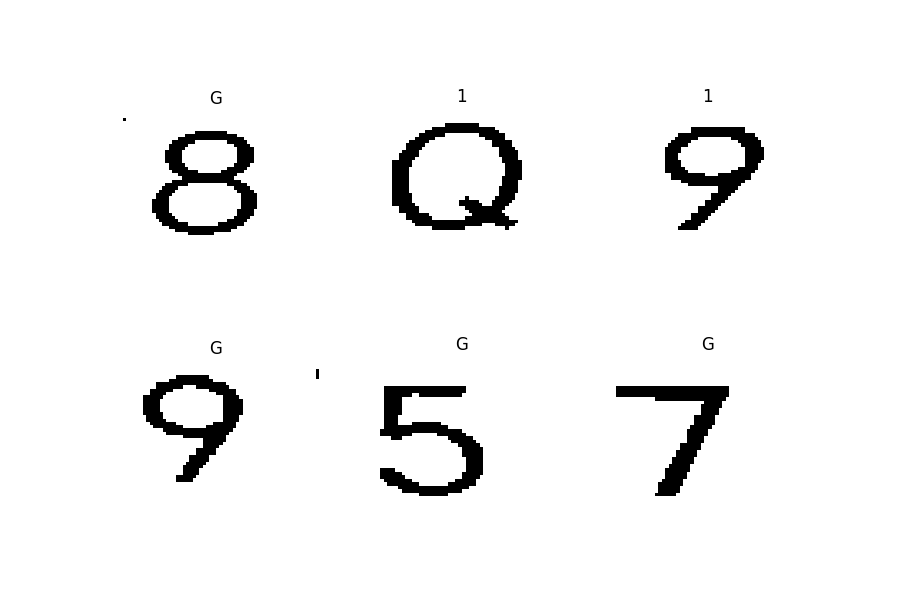

In [ ]:
n = len(digits)
cols = min(8, max(1, int(np.ceil(np.sqrt(n)))))
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.array([axes])
elif cols == 1:
    axes = np.array([[ax] for ax in axes])

for idx, digit in enumerate(digits):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c]
    digit = to_bnw(digit)
    # digit = cv2.resize(digit, (28, 28), interpolation=cv2.INTER_AREA)
    ax.imshow(digit, cmap="gray")

    text = emnist_predictor.predict(digit, limit_characters="0123456789JKQA")
    # text = pytesseract.image_to_string(digit, config='--psm 7').strip()

    # results = eocr.readtext(digit)
    # if not results:
    #     text = "None"
    # else:
    #     # Get the result with highest confidence
    #     best_result = max(results, key=lambda x: x[2])
    #     text = best_result[1]

    # results = pocr.predict(cv2.cvtColor(digit, cv2.COLOR_GRAY2RGB))[0]
    # if len(results["rec_scores"]) > 0:
    #     best_result = np.argmax(results["rec_scores"])
    #     text = results["rec_texts"][best_result]  # Extract text
    # else:
    #     text = "None"

    ax.set_title(text)
    ax.set_axis_off()
    

# Hide any unused axes
for k in range(n, rows*cols):
    r = k // cols
    c = k % cols
    axes[r, c].set_visible(False)

plt.show()

In [13]:
results

NameError: name 'results' is not defined

In [ ]:
img = player_cards

# Read image
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# Create mask for black text
# Black has low saturation and low value
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 50])
black_mask = cv2.inRange(hsv, lower_black, upper_black)

# Create mask for red text
# Red wraps around in HSV (0-10 and 170-180)
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([180, 255, 255])

red_mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
red_mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
red_mask = cv2.bitwise_or(red_mask1, red_mask2)

# Combine masks
combined_mask = cv2.bitwise_or(black_mask, red_mask)

# Create white background
result = np.ones_like(img) * 255

# Apply mask to keep only black and red text
result[combined_mask > 0] = img[combined_mask > 0]

# Convert to PIL Image for pytesseract
result_gray = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)

custom_config = "--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789JKQA"

In [ ]:
blurred = cv2.GaussianBlur(result_gray, (5, 5), 0)
kernel = np.ones((2, 2), np.uint8)
blurred = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel)
cutoff = 196
blurred[blurred > cutoff] = 255
blurred[blurred <= cutoff] = 0

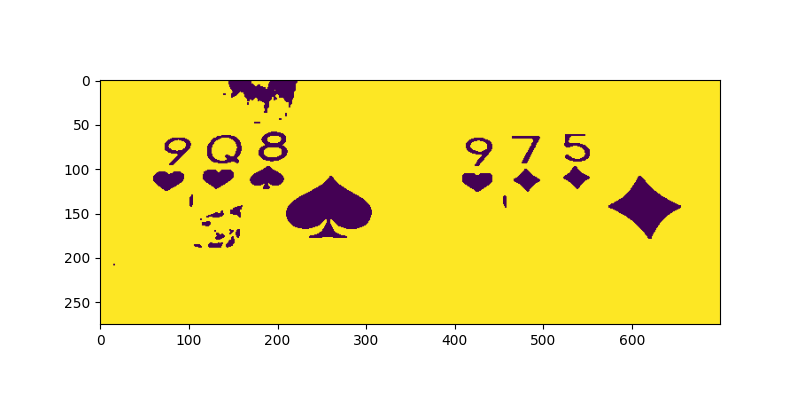

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.imshow(blurred)

In [ ]:
text = pytesseract.image_to_string(blurred, lang='eng', config=custom_config)
print(text)

983



In [ ]:
import easyocr
reader = easyocr.Reader(['en'])
result = reader.readtext(blurred)
text = ' '.join([detection[1] for detection in result])
print(text)

275


In [ ]:
from paddleocr import PaddleOCR
ocr = PaddleOCR(lang='en')
result = ocr.predict(np.stack([result_gray, result_gray, result_gray], axis=2))
text = ' '.join([line[1][0] for line in result[0]])
print(text)

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/UVDoc`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/UVDoc`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/maxim/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)

n a o t o e e e e e e e i e e


In [ ]:
result_gray[..., np.newaxis].shape

(275, 700, 1)

In [ ]:
hierarchy

array([[[   1,   -1,   -1,   -1],
        [   2,    0,   -1,   -1],
        [   3,    1,   -1,   -1],
        ...,
        [1829, 1827,   -1, 1826],
        [  -1, 1828,   -1, 1826],
        [  -1, 1826,   -1,   -1]]], shape=(1, 1831, 4), dtype=int32)

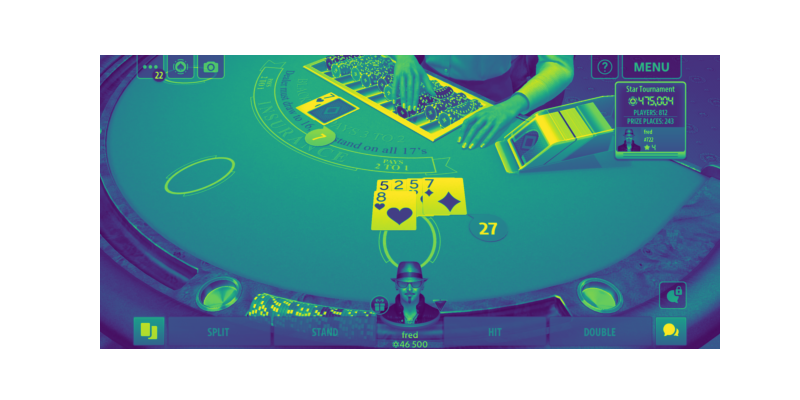

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(gray)
ax.set_axis_off()